# Machine Learning Systems for Sleep Quality Assessment Based on EEG Signals

---

* **Author**: Carmen-Theodora Craciun
* **Previos step**:
  * all ETL steps from folder `/datasets_ETL`
  * Feature extraction step
* **The purpose of this Notebook**:
* **Datasets**:
  * [Sleep-EDFX Database](https://www.physionet.org/content/sleep-edfx/1.0.0/) - channel EEG Fpz-Cz
  * [University College Dublin Sleep Apnea Database](https://physionet.org/content/ucddb/1.0.0/) - channel EEG C3-A2
  * [Haaglanden Medisch Centrum sleep staging database (PhysioNet)](https://physionet.org/content/hmc-sleep-staging/1.1/recordings/#files-panel) - channel EEG C4-M1
* **Input**:
    * `ML_train_features.csv`
    * `ML_test_features.csv`
    * `ML_test_features.csv`
    * `generic_models_functions.py` - helper methods for the models
    * `generic_dataset_functions_ml.py` - helper methods for transforming the dataset



# Imports

In [1]:
from google.colab import drive
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import time

from sklearn.mixture import GaussianMixture
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.naive_bayes import GaussianNB

In [2]:
drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/sleep_data'
helper_functions_path = base_path + '/helper_functions'

sys.path.append(helper_functions_path)

import ml_utils as ml_utils

Mounted at /content/drive


# Datasets

In [4]:
df_train = pd.read_csv(base_path + '/process_dataset/ml_dataset/train_features.csv')
df_val = pd.read_csv(base_path + '/process_dataset/ml_dataset/val_features.csv')

In [5]:
X_train = df_train.drop('Label', axis=1)
y_train = df_train['Label']

X_val = df_val.drop('Label', axis=1)
y_val = df_val['Label']

## Add only Lag/ Load

In [7]:
df_train_raw_basic = ml_utils.extract_basic_temporal_features(df_train)
df_val_raw_basic = ml_utils.extract_basic_temporal_features(df_val)

X_train_raw_basic = df_train_raw_basic.drop(columns=['Label'])
y_train_raw_basic = df_train_raw_basic['Label']
X_val_raw_basic = df_val_raw_basic.drop(columns=['Label'])
y_val_raw_basic = df_val_raw_basic['Label']

## Normalize Zscore + Lag/ Load

In [8]:
cols_to_normalize = [
    'Mean', 'Std', 'Skewness', 'Kurtosis', 'Zero_Crossings',
    'Mobility', 'Complexity', 'Spectral_Entropy',
    'Abs_Delta', 'Abs_Theta', 'Abs_Alpha', 'Abs_Sigma', 'Abs_Beta', 'Abs_Total',
    'Rel_Delta', 'Rel_Theta', 'Rel_Alpha', 'Rel_Sigma', 'Rel_Beta'
]

df_train_norm = ml_utils.normalize_by_subject(df_train, cols_to_normalize)
df_val_norm = ml_utils.normalize_by_subject(df_val, cols_to_normalize)

## Lag/ Leag + Z-Score

In [9]:
df_train_norm_basic = ml_utils.extract_basic_temporal_features(df_train_norm)
df_val_norm_basic = ml_utils.extract_basic_temporal_features(df_val_norm)

df_train_norm_basic['Dataset_Source'] = df_train_norm_basic['Dataset_Source'].astype('category')
df_val_norm_basic['Dataset_Source'] = df_val_norm_basic['Dataset_Source'].astype('category')

X_train_norm_basic = df_train_norm_basic.drop(columns=['Label'])
y_train_norm_basic = df_train_norm_basic['Label']
X_val_norm_basic = df_val_norm_basic.drop(columns=['Label'])
y_val_norm_basic = df_val_norm_basic['Label']

## Temporal feature advances + Z-Score

In [10]:
df_train_norm_enhanced = ml_utils.extract_enhanced_temporal_features(df_train_norm)
df_val_norm_enhanced = ml_utils.extract_enhanced_temporal_features(df_val_norm)

cols_to_drop = ['Subject_ID', 'Dataset_Source', 'Label']

X_train_norm_enhanced = df_train_norm_enhanced.drop(columns=cols_to_drop, errors='ignore')
y_train_norm_enhanced = df_train_norm_enhanced['Label']
X_val_norm_enhanced = df_val_norm_enhanced.drop(columns=cols_to_drop, errors='ignore')
y_val_norm_enhanced = df_val_norm_enhanced['Label']

## Standard Scalar

In [11]:
scaler = StandardScaler()
X_train_std_scalar = scaler.fit_transform(X_train_norm_basic.fillna(0))
X_val_std_scalar = scaler.transform(X_val_norm_basic.fillna(0))

# Vitebri

In [13]:
def calculate_transition_matrix(df_train, label_col='Label', subject_col='Subject_ID', n_classes=5):
    '''
     It calculates a state transition matrix from a given DataFrame of sleep stage labels.
     It models the probability of transitioning from one sleep stage to another.

    Parameters:
      - df_train (pd.DataFrame): DataFrame containing sleep stage labels.
      - label_col (str): Name of the column containing sleep stage labels.
      - subject_col (str): Name of the column containing subject IDs.

    Returns:
      - trans_mat (np.array): State transition matrix.
    '''
    trans_mat = np.ones((n_classes, n_classes))

    for subj, group in df_train.groupby(subject_col):
        labels = group[label_col].values

        for i in range(len(labels) - 1):
            current_state = int(labels[i])
            next_state = int(labels[i+1])
            trans_mat[current_state, next_state] += 1

    row_sums = trans_mat.sum(axis=1)
    trans_mat = trans_mat / row_sums[:, np.newaxis]

    return trans_mat

In [14]:
def viterbi(obs_probs, trans_mat, start_prob):
    '''
    Adapted Viterbi algorithm to find the most likely "path" (sequence of sleep stages)
    using emission probabilities from a classifier (e.g. Logistic Regression).

    Parameters:
    - obs_probs (np.array): Matrix [n_epochs, n_classes] with probabilities from the model (predict_sample).
    - trans_mat (np.array): Transition matrix [n_classes, n_classes].
    - start_prob (np.array): Initial probabilities for each class.

    Returns:
    - best_path (np.array): Optimal sequence of stages (path with maximum probability).
    '''
    n_epochs, n_classes = obs_probs.shape

    eps = 1e-10
    log_start_prob = np.log(start_prob + eps)
    log_trans_mat = np.log(trans_mat + eps)
    log_obs_probs = np.log(obs_probs + eps)

    V = np.zeros((n_epochs, n_classes))
    ptr = np.zeros((n_epochs, n_classes), dtype=int)

    V[0, :] = log_start_prob + log_obs_probs[0, :]

    for t in range(1, n_epochs):
        for j in range(n_classes):
            seq_probs = V[t-1, :] + log_trans_mat[:, j] + log_obs_probs[t, j]

            V[t, j] = np.max(seq_probs)
            ptr[t, j] = np.argmax(seq_probs)

    best_path = np.zeros(n_epochs, dtype=int)

    best_path[-1] = np.argmax(V[-1, :])

    for t in range(n_epochs - 2, -1, -1):
        best_path[t] = ptr[t + 1, best_path[t+1]]

    return best_path

# Models

## Gaussian Naive Bayes

Train time: 0.19 seconds
Accuracy 0.5948

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.61      0.62      0.61     10361
          N1       0.33      0.16      0.21      6930
          N2       0.62      0.72      0.66     20785
          N3       0.57      0.79      0.66      6474
         REM       0.67      0.46      0.54      7574

    accuracy                           0.59     52124
   macro avg       0.56      0.55      0.54     52124
weighted avg       0.58      0.59      0.58     52124



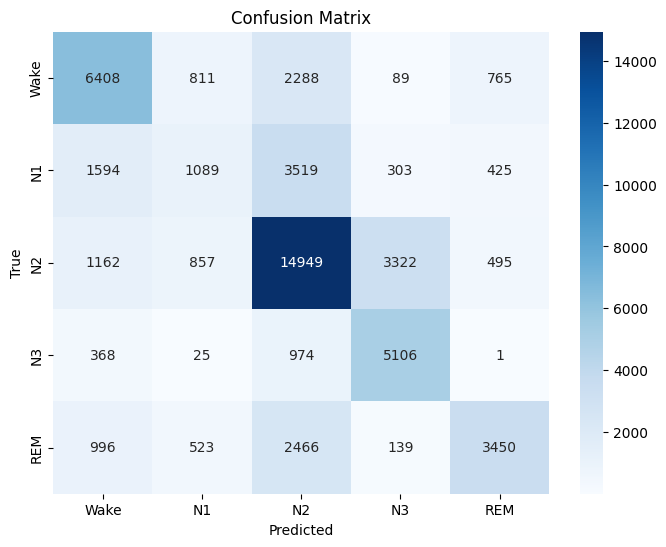

In [15]:
pt = PowerTransformer(method='yeo-johnson', standardize=True)
X_train_pt = pt.fit_transform(X_train_norm_basic.fillna(0))
X_val_pt = pt.transform(X_val_norm_basic.fillna(0))

pca_gnb = PCA(n_components=0.95, random_state=42)
X_train_pca = pca_gnb.fit_transform(X_train_pt)
X_val_pca = pca_gnb.transform(X_val_pt)

gnb_model = GaussianNB(var_smoothing=1e-3)
start_time = time.time()
gnb_model.fit(X_train_pca, y_train_norm_basic)
end_time = time.time()
print(f"Train time: {end_time - start_time:.2f} seconds")

obs_probs = gnb_model.predict_proba(X_val_pca)

trans_mat = calculate_transition_matrix(df_train_norm, label_col='Label', subject_col='Subject_ID')
fair_trans_mat = trans_mat.copy()

for i in range(5):
    fair_trans_mat[i, i] *= 0.8
    fair_trans_mat[i, :] /= fair_trans_mat[i, :].sum()

start_prob = np.array([0.90, 0.02, 0.02, 0.03, 0.03])

df_eval_gnb_hmm = pd.DataFrame({
    'Subject_ID': df_val_norm['Subject_ID'],
    'Label': y_val_norm_basic,
    'Pred_HMM': 0
})

for subj in df_eval_gnb_hmm['Subject_ID'].unique():
    idx = df_eval_gnb_hmm['Subject_ID'] == subj
    subj_probs = obs_probs[idx]

    best_path = viterbi(subj_probs, fair_trans_mat, start_prob)
    df_eval_gnb_hmm.loc[idx, 'Pred_HMM'] = best_path

ml_utils.evaluete_model(df_eval_gnb_hmm['Label'], df_eval_gnb_hmm['Pred_HMM'])

## Logistic Regression

Train time: 80.38 seconds
Accuracy 0.6916

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.77      0.75      0.76     10361
          N1       0.41      0.28      0.34      6930
          N2       0.78      0.71      0.75     20785
          N3       0.62      0.86      0.72      6474
         REM       0.64      0.79      0.71      7574

    accuracy                           0.69     52124
   macro avg       0.64      0.68      0.65     52124
weighted avg       0.69      0.69      0.68     52124



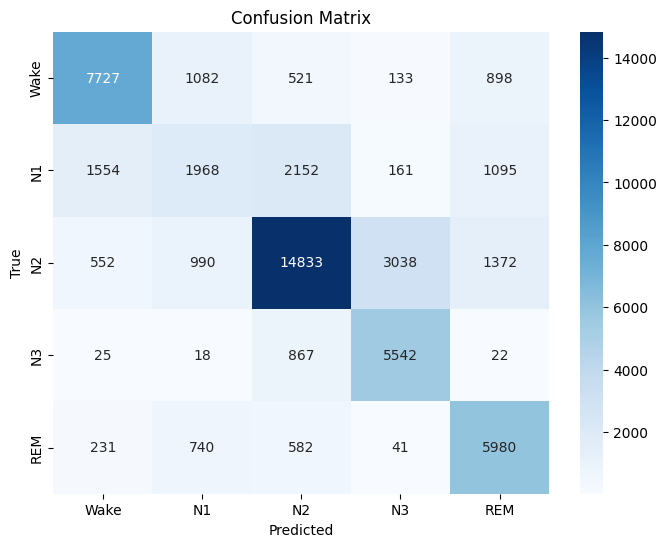

In [ ]:
scaler_lr = StandardScaler()
X_train_lr_scaled = scaler_lr.fit_transform(X_train_norm_enhanced.fillna(0))
X_val_lr_scaled = scaler_lr.transform(X_val_norm_enhanced.fillna(0))

lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=2000,
    solver='lbfgs',
    n_jobs=-1,
    random_state=42
)
start_time = time.time()
lr_model.fit(X_train_lr_scaled, y_train_norm_enhanced)
end_time = time.time()
print(f"Train time: {end_time - start_time:.2f} seconds")

obs_probs_lr = lr_model.predict_proba(X_val_lr_scaled)

df_eval_lr_hmm = pd.DataFrame({
    'Subject_ID': df_val_norm['Subject_ID'],
    'Label': y_val_norm_enhanced,
    'Pred_HMM': 0
})

for subj in df_eval_lr_hmm['Subject_ID'].unique():
    idx = df_eval_lr_hmm['Subject_ID'] == subj
    subj_probs = obs_probs_lr[idx]

    best_path = viterbi(subj_probs, fair_trans_mat, start_prob)
    df_eval_lr_hmm.loc[idx, 'Pred_HMM'] = best_path

ml_utils.evaluete_model(df_eval_lr_hmm['Label'], df_eval_lr_hmm['Pred_HMM'])

## Linear Discriminant Analysis (LDA)

Train time: 3.28 seconds
Accuracy 0.6812

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.78      0.69      0.73     10361
          N1       0.48      0.16      0.24      6930
          N2       0.66      0.85      0.75     20785
          N3       0.68      0.68      0.68      6474
         REM       0.69      0.68      0.69      7574

    accuracy                           0.68     52124
   macro avg       0.66      0.61      0.62     52124
weighted avg       0.67      0.68      0.66     52124



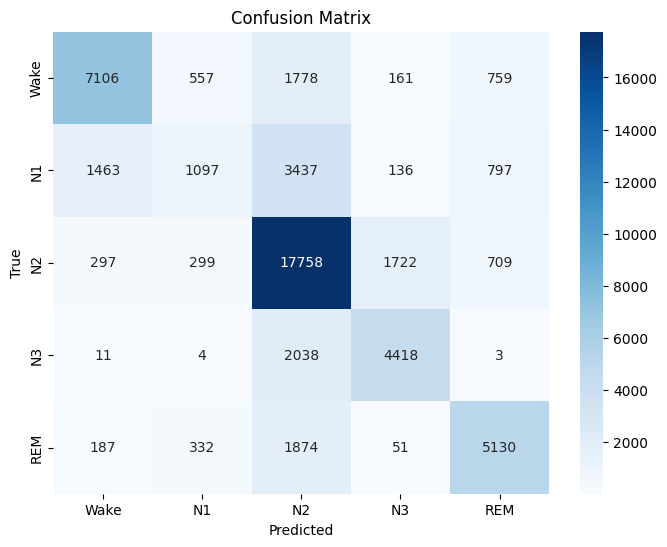

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import pandas as pd

lda_model = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
start_time = time.time()
lda_model.fit(X_train_lr_scaled, y_train_norm_enhanced)
end_time = time.time()
print(f"Train time: {end_time - start_time:.2f} seconds")

obs_probs_lda = lda_model.predict_proba(X_val_lr_scaled)

df_eval_lda_hmm = pd.DataFrame({
    'Subject_ID': df_val_norm['Subject_ID'],
    'Label': y_val_norm_enhanced,
    'Pred_HMM': 0
})

for subj in df_eval_lda_hmm['Subject_ID'].unique():
    idx = df_eval_lda_hmm['Subject_ID'] == subj
    subj_probs = obs_probs_lda[idx]

    best_path = viterbi(subj_probs, fair_trans_mat, start_prob)
    df_eval_lda_hmm.loc[idx, 'Pred_HMM'] = best_path

ml_utils.evaluete_model(df_eval_lda_hmm['Label'], df_eval_lda_hmm['Pred_HMM'])

## QAD + GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV

qda_pipeline = Pipeline([
    ('pt', PowerTransformer(method='yeo-johnson', standardize=True)),
    ('pca', PCA(random_state=42)),
    ('qda', QuadraticDiscriminantAnalysis())
])

param_grid = {
    'pca__n_components': [0.90, 0.95, 0.99],
    'qda__reg_param': [0.01, 0.1, 0.3, 0.5, 0.8]
}

grid_search = GridSearchCV(qda_pipeline, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
start_time = time.time()
grid_search.fit(X_train_norm_enhanced, y_train_norm_enhanced)
end_time = time.time()
print(f"Train time: {end_time - start_time:.2f} seconds")

print(f"Best parameters for QAD: {grid_search.best_params_}")

best_qda = grid_search.best_estimator_
obs_probs_qda_opt = best_qda.predict_proba(X_val_norm_enhanced)

Train time: 1562.26 seconds
Best parameters for QAD: {'pca__n_components': 0.99, 'qda__reg_param': 0.8}


Train time: 57.83 seconds
Accuracy 0.6591

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.67      0.77      0.72     10361
          N1       0.35      0.30      0.32      6930
          N2       0.77      0.69      0.73     20785
          N3       0.63      0.75      0.69      6474
         REM       0.63      0.68      0.66      7574

    accuracy                           0.66     52124
   macro avg       0.61      0.64      0.62     52124
weighted avg       0.66      0.66      0.66     52124



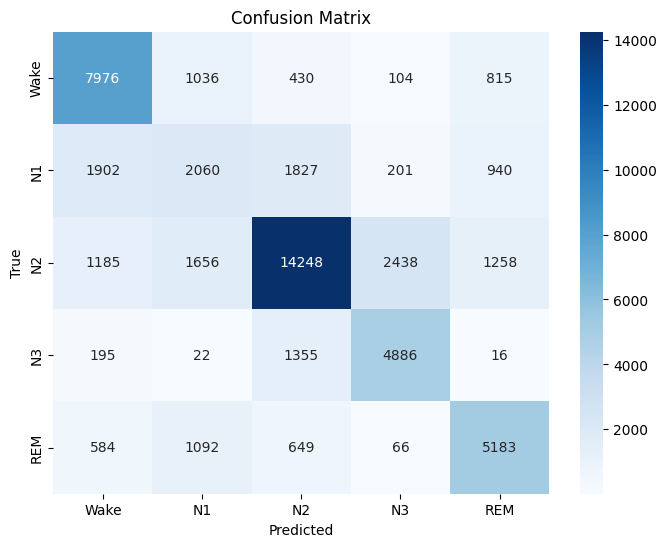

In [ ]:
trans_mat = calculate_transition_matrix(df_train_norm, label_col='Label', subject_col='Subject_ID')
fair_trans_mat = trans_mat.copy()

for i in range(5):
    fair_trans_mat[i, i] *= 0.8
    fair_trans_mat[i, :] /= fair_trans_mat[i, :].sum()

start_prob = np.array([0.90, 0.02, 0.02, 0.03, 0.03])

final_qda_pipeline = Pipeline(
    [('pt', PowerTransformer(method='yeo-johnson', standardize=True)),
     ('pca', PCA(n_components=0.99, random_state=42)),
     ('qda', QuadraticDiscriminantAnalysis(reg_param=0.8))])

start_time = time.time()
final_qda_pipeline.fit(X_train_norm_enhanced, y_train_norm_enhanced)
end_time = time.time()
print(f"Train time: {end_time - start_time:.2f} seconds")

y_pred_qda_opt = final_qda_pipeline.predict(X_val_norm_enhanced)
obs_probs_qda_opt = final_qda_pipeline.predict_proba(X_val_norm_enhanced)

df_eval_qda_hmm = pd.DataFrame({
    'Subject_ID': df_val_norm['Subject_ID'],
    'Label': y_val_norm_enhanced,
    'Pred_HMM': 0
})

for subj in df_eval_qda_hmm['Subject_ID'].unique():
    idx = df_eval_qda_hmm['Subject_ID'] == subj

    subj_probs = obs_probs_qda_opt[idx]

    best_path = viterbi(subj_probs, fair_trans_mat, start_prob)
    df_eval_qda_hmm.loc[idx, 'Pred_HMM'] = best_path

ml_utils.evaluete_model(df_eval_qda_hmm['Label'], df_eval_qda_hmm['Pred_HMM'])

## GMM

Train time: 60.49 seconds
Accuracy 0.5196

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.57      0.54      0.56     10361
          N1       0.24      0.28      0.26      6930
          N2       0.70      0.51      0.59     20785
          N3       0.57      0.68      0.62      6474
         REM       0.41      0.59      0.48      7574

    accuracy                           0.52     52124
   macro avg       0.50      0.52      0.50     52124
weighted avg       0.55      0.52      0.53     52124



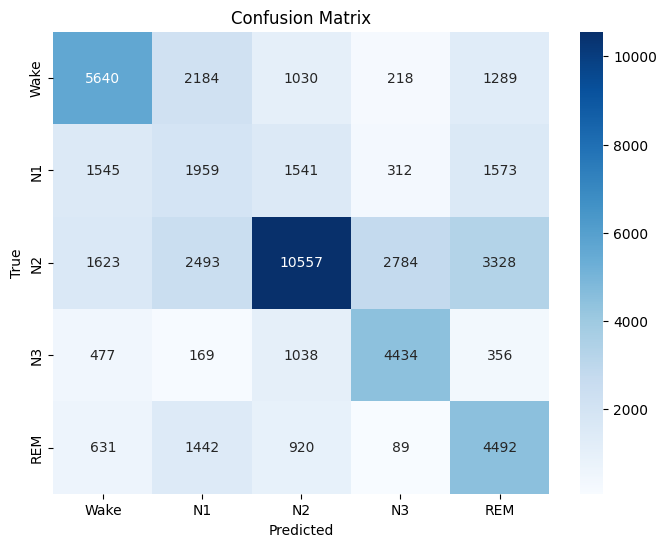

In [ ]:
class GMMClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, n_components=3, covariance_type='full'):
        self.n_components = n_components
        self.covariance_type = covariance_type
        self.models_ = {}
        self.classes_ = None
        self.priors_ = None

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.priors_ = np.zeros(len(self.classes_))

        for i, c in enumerate(self.classes_):
            X_c = X[y == c]
            self.priors_[i] = len(X_c) / len(X)

            gmm = GaussianMixture(n_components=self.n_components,
                                  covariance_type=self.covariance_type,
                                  random_state=42)
            gmm.fit(X_c)
            self.models_[c] = gmm
        return self

    def predict_proba(self, X):
        log_probs = np.zeros((X.shape[0], len(self.classes_)))
        for i, c in enumerate(self.classes_):
            log_probs[:, i] = self.models_[c].score_samples(X) + np.log(self.priors_[i])

        log_probs_max = log_probs.max(axis=1, keepdims=True)
        probs = np.exp(log_probs - log_probs_max)
        return probs / probs.sum(axis=1, keepdims=True)

    def predict(self, X):
        probs = self.predict_proba(X)
        return self.classes_[np.argmax(probs, axis=1)]

gmm_pipeline = Pipeline([
    ('pt', PowerTransformer(method='yeo-johnson', standardize=True)),
    ('pca', PCA(n_components=0.95, random_state=42)),
    ('gmm_clf', GMMClassifier(n_components=3, covariance_type='diag'))
])

start_time = time.time()
gmm_pipeline.fit(X_train_norm_enhanced, y_train_norm_enhanced)
end_time = time.time()
print(f"Train time: {end_time - start_time:.2f} seconds")

y_pred_gmm = gmm_pipeline.predict(X_val_norm_enhanced)
obs_probs_gmm = gmm_pipeline.predict_proba(X_val_norm_enhanced)

ml_utils.evaluete_model(y_val_norm_enhanced, y_pred_gmm)

# Cross Validation

In [ ]:
def get_linear_importance(model, feature_names, model_name):
    importances = np.mean(np.abs(model.coef_), axis=0)

    df_imp = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })

    df_imp = df_imp.sort_values(by='Importance', ascending=False).reset_index(drop=True)

    plt.figure(figsize=(12, 8))
    sns.barplot(data=df_imp.head(15), x='Importance', y='Feature', hue='Feature', palette='mako', legend=False)

    plt.title(f'Top 15 Feature Importances - {model_name}', fontsize=16)
    plt.xlabel('Gini / Split', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.tight_layout()
    plt.show()

    return df_imp

In [ ]:
X_full_norm_basic = pd.concat([X_train_norm_basic, X_val_norm_basic], ignore_index=True)
y_full_norm_basic = pd.concat([y_train_norm_basic, y_val_norm_basic], ignore_index=True)

X_full_norm_enhanced = pd.concat([X_train_norm_enhanced, X_val_norm_enhanced], ignore_index=True)
y_full_norm_enhanced = pd.concat([y_train_norm_enhanced, y_val_norm_enhanced], ignore_index=True)

scaler_lr = StandardScaler()
X_train_lr_scaled = scaler_lr.fit_transform(X_train_norm_enhanced.fillna(0))
X_val_lr_scaled = scaler_lr.transform(X_val_norm_enhanced.fillna(0))

X_full_lr_scaled = pd.concat([
    pd.DataFrame(X_train_lr_scaled, columns=X_train_norm_enhanced.columns),
    pd.DataFrame(X_val_lr_scaled, columns=X_val_norm_enhanced.columns)
], ignore_index=True)

## Linear Regresion

In [ ]:
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=2000,
    solver='lbfgs',
    n_jobs=-1,
    random_state=42
)

best_lr_cv, mean_acc_lr = ml_utils.cross_validation_model(
    model=lr_model,
    X=X_full_lr_scaled,
    y=y_full_norm_enhanced,
    n_splits=5,
    model_name="Logistic_Regression",
    save_path="./models"
)

=== Cross validation for Logistic_Regression (5 folds) ===
Fold 1: Accuracy = 0.6845 -> New best!

Fold 2: Accuracy = 0.6868 -> New best!

Fold 3: Accuracy = 0.6847

Fold 4: Accuracy = 0.6842

Fold 5: Accuracy = 0.6869 -> New best!


Final results Logistic_Regression:
Mean accuracy: 0.6854 (± 0.0012)
Best model save at: ./models/best_Logistic_Regression_model.pkl



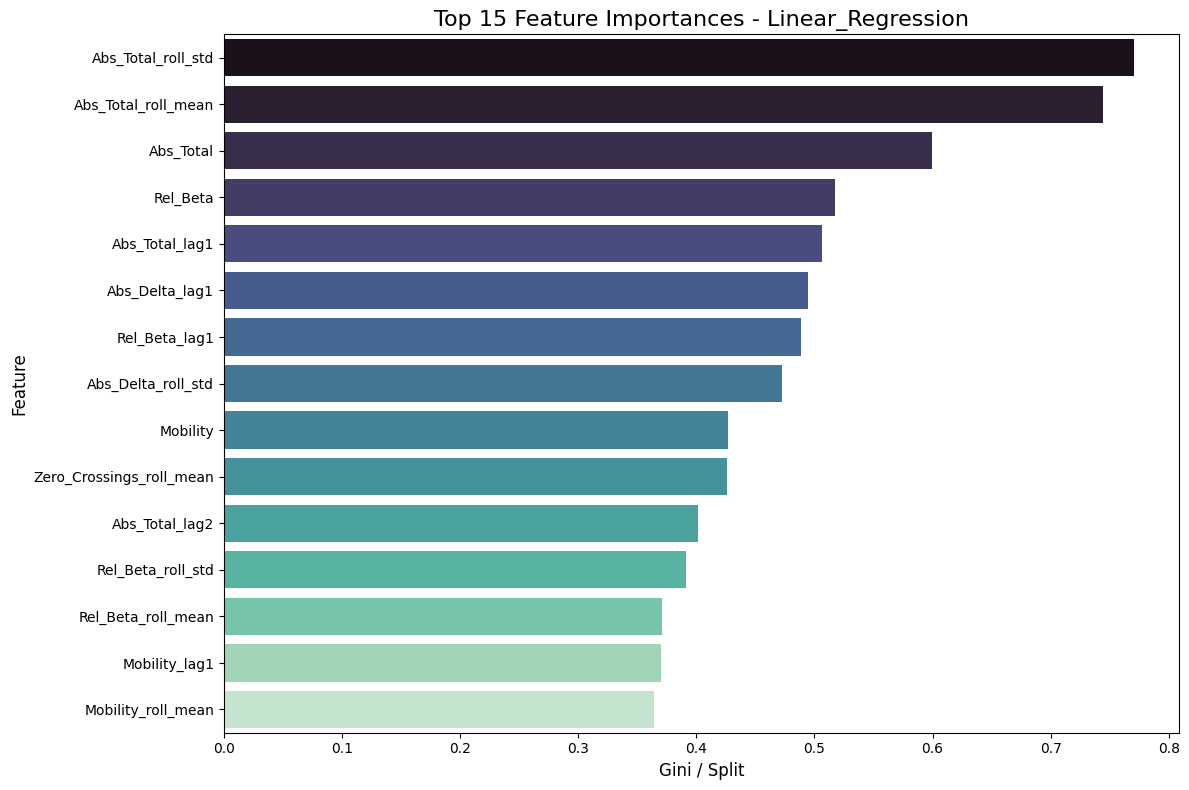

In [ ]:
df_importance_lr = get_linear_importance(
    model=best_lr_cv,
    feature_names=X_full_lr_scaled.columns,
    model_name="Linear_Regression"
)

## Linear Discriminat Analysis

In [ ]:
lda_model = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')

best_lda_cv, mean_acc_lda = ml_utils.cross_validation_model(
    model=lda_model,
    X=X_full_lr_scaled,
    y=y_full_norm_enhanced,
    n_splits=5,
    model_name="Linear_Discriminant_Analysis",
    save_path="./models"
)

=== Cross validation for Linear_Discriminant_Analysis (5 folds) ===
Fold 1: Accuracy = 0.6903 -> New best!

Fold 2: Accuracy = 0.6957 -> New best!

Fold 3: Accuracy = 0.6905

Fold 4: Accuracy = 0.6902

Fold 5: Accuracy = 0.6932


Final results Linear_Discriminant_Analysis:
Mean accuracy: 0.6920 (± 0.0022)
Best model save at: ./models/best_Linear_Discriminant_Analysis_model.pkl



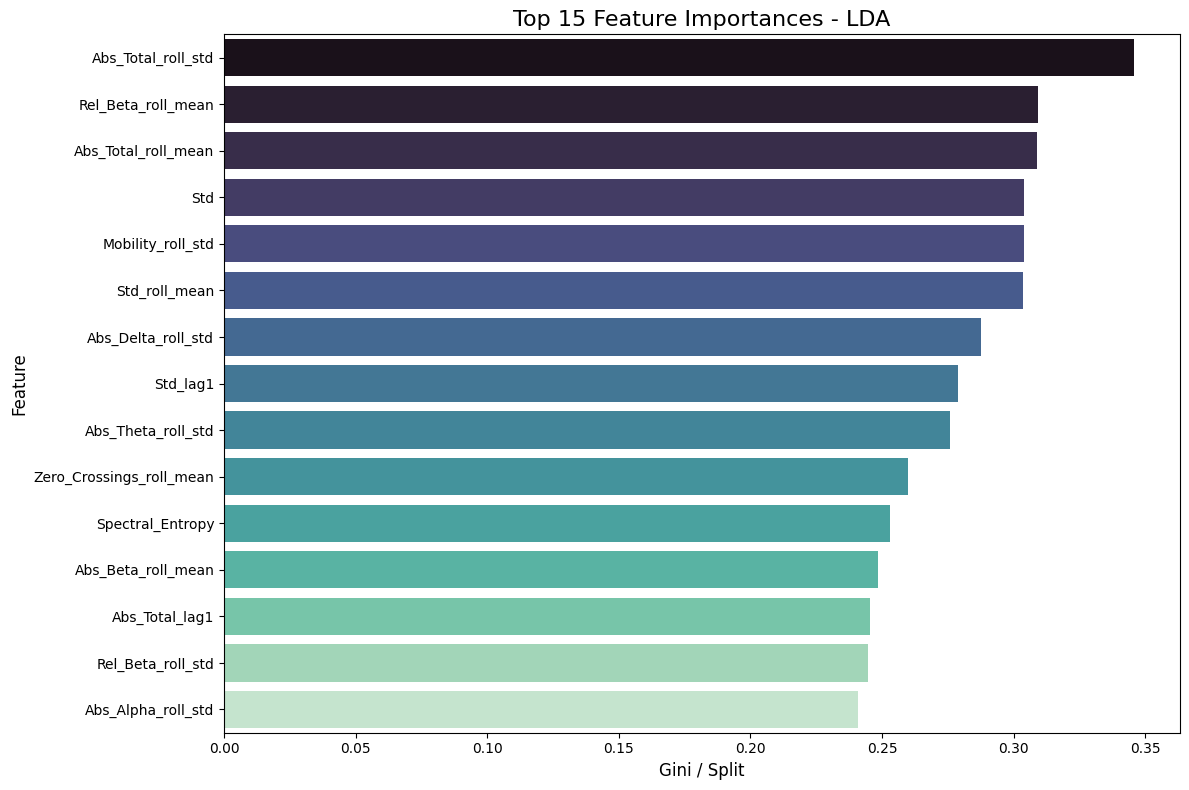

In [ ]:
df_importance_lr = get_linear_importance(
    model=best_lda_cv,
    feature_names=X_full_lr_scaled.columns,
    model_name="LDA"
)

# Conclusion

On such a noisy dataset, the best part of probabilistic models is that they are very fast. However, the average accuracy of 0.6920 that we got as a result from LDA is not enough for a medical problem.

Due to the speed, we can think that they will have a better performance in hybrid models.